In [1]:
%load_ext autoreload
%autoreload 2

In [53]:
import numpy as np
import torch
from models.linear_probes import linear_probe, linear_probe_tuned
from models.feature_generation import build_feature_bank, extract_encoder, extract_feature,pool_features
from preprocessing.dataset import PipistrelleDataset
from evaluation.metrics import compute_cv_stats,plot_model_comparison,label_confusion
import pandas as pd
from sklearn.metrics import average_precision_score
from evaluation.metrics import compute_metrics,compile_results,generate_metrics_table2,plot_comprehensive_boxplots,plot_comprehensive_mlp_boxplots
from evaluation.metrics import plot_comprehensive_calibration,plot_mlp_balancing_boxplots
from models.MLP_balancing import balancing_mlp,balancing_mlp_val,data_augmented_mlp
import pickle
from pathlib import Path
import os
from evaluation.statistical_tests import perform_encoder_statistical_analysis,evaluate_and_plot_mlp_strategies

In [5]:
dir = Path(os.getcwd()).resolve().parent 
path = str(dir / "models" / "features")
X_per2 = np.load(path + "\\perch_features.npz")['features']
X_per2_pooled = X_per2
y = np.load(path + "\\perch_features.npz")['labels']
label_names = ['Type A', 'Type B', 'Type C', 'Type D', 'Echo']

In [32]:
print(y[48])

[1. 0. 0. 0. 0.]


In [14]:
balancing_results =balancing_mlp_val(X_per2_pooled, y, n_split_out=5,n_split_in=5, num_trials=5,random_state=42)

Starting Trial 1/5 with random_state=42...
  Tuning and evaluating model: MLP_Baseline
    Evaluating fold 1/5
    Evaluating fold 2/5
    Evaluating fold 3/5
    Evaluating fold 4/5
    Evaluating fold 5/5
  Tuning and evaluating model: MLP_ClassWeights
    Evaluating fold 1/5
    Evaluating fold 2/5
    Evaluating fold 3/5
    Evaluating fold 4/5
    Evaluating fold 5/5
  Tuning and evaluating model: MLP_FocalLoss
    Evaluating fold 1/5
    Evaluating fold 2/5
    Evaluating fold 3/5
    Evaluating fold 4/5
    Evaluating fold 5/5
  Tuning and evaluating model: MLP_Oversampled
    Evaluating fold 1/5
Final counts: [ 95 108 163  95 266]
    Evaluating fold 2/5
Final counts: [ 95 104 159  95 273]
    Evaluating fold 3/5
Final counts: [ 95 105 182  95 263]
    Evaluating fold 4/5
Final counts: [ 94 110 159  94 263]
    Evaluating fold 5/5
Final counts: [ 95  96 156  95 262]
Starting Trial 2/5 with random_state=43...
  Tuning and evaluating model: MLP_Baseline
    Evaluating fold 1/5
  

In [45]:
dir = Path(os.getcwd()).resolve().parent 
root_dir = str(dir / "data" / "xenocanto-dataset")
csv_data = str(dir / "data" / "bat_metadata.csv")
augmentation_results = data_augmented_mlp(csv_data,root_dir,X_per2_pooled,y, n_split=5, num_trials=5,random_state=42)

Starting Trial 1/5 with random_state=42...
  Tuning and evaluating model: MLP_Baseline
    Evaluating fold 1/5
Final counts: [ 38  74 134  38 198]
Dataset type: <class 'preprocessing.dataset.PipistrelleDataset'>


Extracting perch2: 100%|██████████| 262/262 [25:49<00:00,  5.92s/it]


Train features extracted
Model trained
    Evaluating fold 2/5
Final counts: [ 38  73 136  38 203]
Dataset type: <class 'preprocessing.dataset.PipistrelleDataset'>


Extracting perch2: 100%|██████████| 259/259 [26:06<00:00,  6.05s/it]


Train features extracted
Model trained
    Evaluating fold 3/5
Final counts: [ 38  70 141  38 199]
Dataset type: <class 'preprocessing.dataset.PipistrelleDataset'>


...

Train features extracted
Model trained
    Evaluating fold 4/5
Final counts: [ 38  70 134  38 204]
Dataset type: <class 'preprocessing.dataset.PipistrelleDataset'>


Extracting perch2: 100%|██████████| 262/262 [25:47<00:00,  5.91s/it]


Train features extracted
Model trained
    Evaluating fold 5/5
Final counts: [ 38  74 135  38 202]
Dataset type: <class 'preprocessing.dataset.PipistrelleDataset'>


Extracting perch2: 100%|██████████| 261/261 [26:37<00:00,  6.12s/it]


Train features extracted
Model trained


In [46]:
aug_results= augmentation_results

In [ ]:
import pickle

pickle_filename = 'augment_results.pkl'
with open(pickle_filename, 'wb') as pickle_file:
    pickle.dump(aug_results, pickle_file)

In [48]:
with open(pickle_filename, 'rb') as pickle_file:
    aug2_results = pickle.load(pickle_file)

In [51]:
print(aug2_results)

[{'trial': 0, 'model': 'MLP_Baseline', 'mean_AP': np.float64(0.8755499025516148), 'std_AP': np.float64(0.05649975988656685), 'y_true_cv': [array([[0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 1.],
       [0., 0., 1., 0., 1.],
       [0., 0., 1., 0., 1.],
       [1., 1., 1., 0., 0.],
       [1., 0., 0., 0., 0.],
       [0., 0., 1., 0., 1.],
       [0., 0., 1., 0., 1.],
       [0., 0., 1., 0., 1.],
       [0., 0., 1., 0., 1.],
       [0., 0., 1., 0., 1.],
       [0., 0., 0., 1., 1.],
       [0., 0., 0., 1., 1.],
       [0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 1.],
       [0., 1., 0., 0., 1.],
       [0., 1., 0., 0., 1.],
       [0., 0., 0., 1., 1.],
       [0., 1., 0., 0., 0.],
       [1., 1., 0., 0., 0.],
       [0., 1., 1., 0., 0.],
       [0., 1., 0., 0., 1.],
       [0., 1., 0., 0., 0.],
       [0., 0., 0., 1., 1.],
       [0., 0., 1., 0., 1.],
       [0., 0., 1., 0., 1.],
       [0., 1., 1., 0., 1.],
       [0., 0., 1., 

In [43]:
df = pd.read_csv(csv_data)
label_cols = ['type_a', 'type_b', 'type_c', 'type_d', 'echo']
X_paths = df['relative_path'].values
y_labels = df[label_cols].values
print (np.sum(y_labels != y))

0


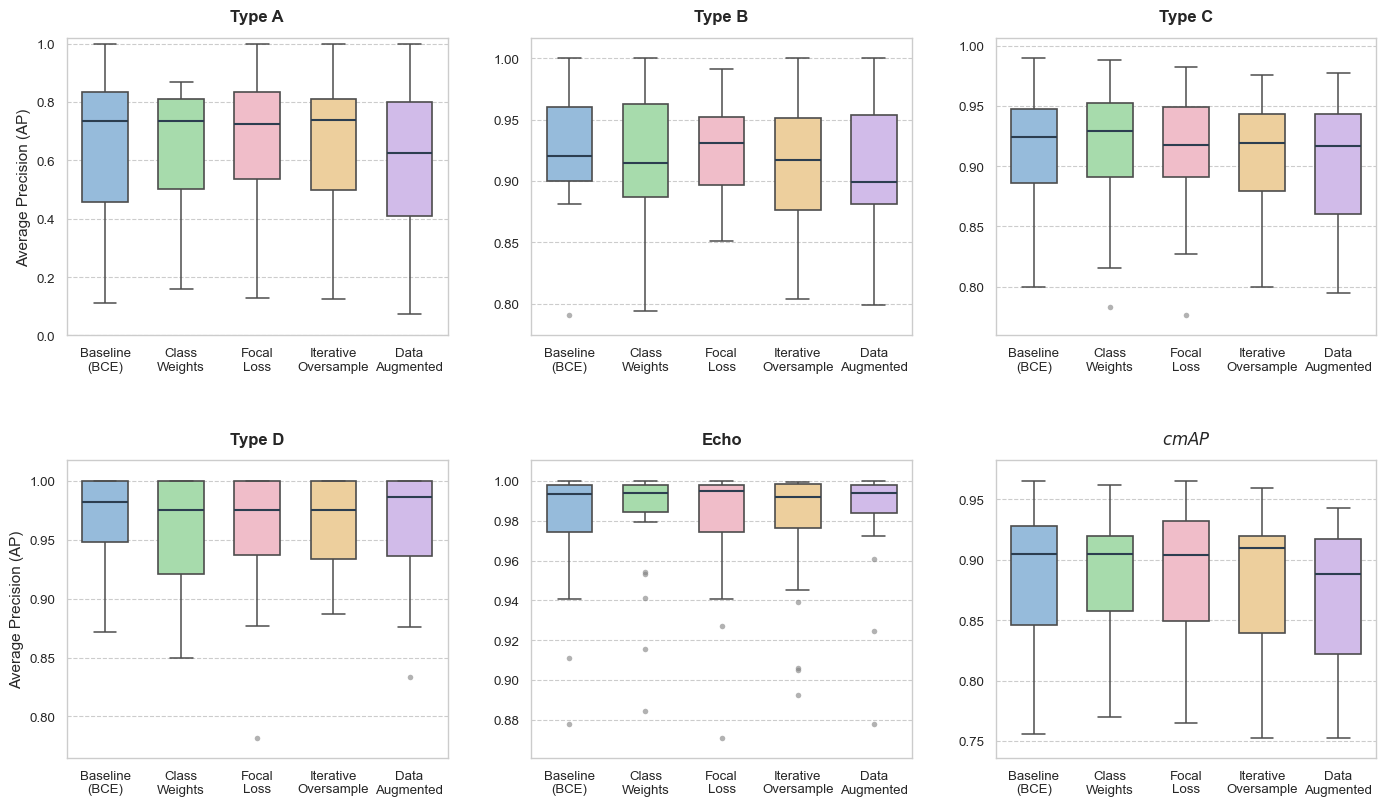

In [61]:
plot_comprehensive_mlp_boxplots(balancing_results, aug_results, label_names=label_names)

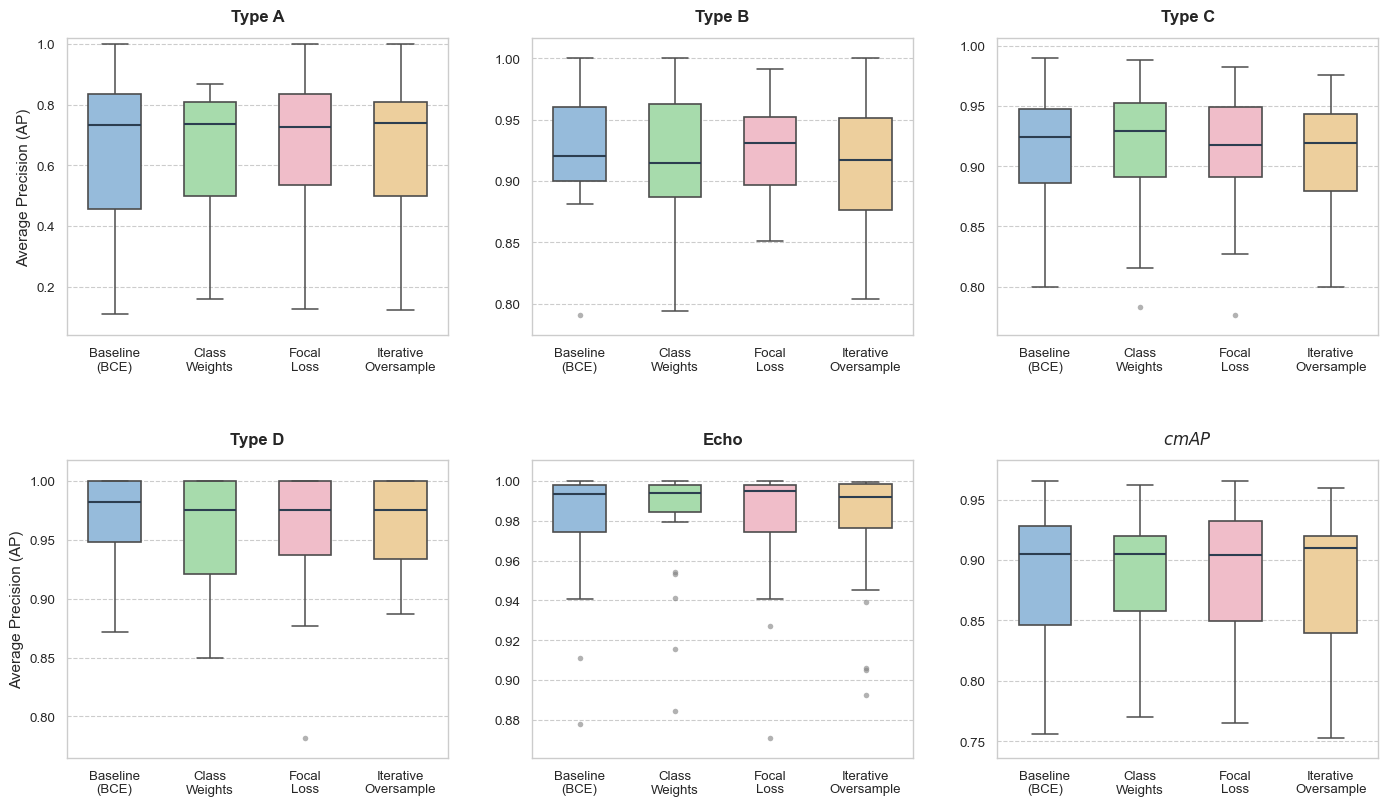

In [15]:
plot_mlp_balancing_boxplots(balancing_results, label_names=label_names)

In [55]:
evaluate_and_plot_mlp_strategies(balancing_results,aug_results, label_names=label_names)

=== Statistical Setup ===
Number of perfectly matched Blocks (N): 125
Strategies evaluated: ['Baseline', 'Class Weights', 'Focal Loss', 'Oversampled', 'Augmented']

=== Friedman Test Results ===
Friedman chi-square Statistic: 5.6246
p-value: 2.2899e-01
Result: No globally significant differences detected. Skipping Post-Hoc heatmap.


In [60]:
from evaluation.tables import  process_folds_to_table
latex_code = process_folds_to_table(balancing_results, aug_results)
with open("balancing_table.tex", "w", encoding="utf-8") as f:
    f.write(latex_code)